<a href="https://colab.research.google.com/github/ubsuny/PHY386/blob/Homework2026/2026/FinalProject/Final_02_RingOfFire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project — Topic 2: Ring of Fire from Earthquake Data (42 pts)

## Learning Outcomes
- Query a public geophysical database (USGS ComCat) with the `libcomcat` Python client — same programmatic spirit as `astroquery` in HW6.
- Engineer features (lat, lon, depth, magnitude) from a real-world catalog.
- Label events by geographic membership in the Pacific Ring of Fire.
- Train k-Nearest Neighbors and Random Forest classifiers; compare them quantitatively.
- Connect the feature importance back to the physics of subduction zones and mid-ocean ridges.
- Visualize decision regions on a world map with `cartopy`.

## GitHub Workflow
Fork → `yourname-final` → pull request into `Homework2026`. Reviewer `@laserlab`, milestone `Final-2026`. See [`pull_request_template_Final.md`](pull_request_template_Final.md).

## Background: The Ring of Fire

The **Pacific Ring of Fire** is the horseshoe-shaped belt of tectonic activity around the Pacific Ocean — the convergent-plate boundaries where the Pacific, Nazca, Cocos, and Juan de Fuca plates subduct beneath the surrounding continental and oceanic plates. About **90% of the world's earthquakes** and most of its volcanoes occur in this belt.

Two physical predictions we can test:
1. **Location dominates.** Earthquakes cluster along plate boundaries. A classifier trained only on (latitude, longitude) should already get most of the signal.
2. **Depth distinguishes.** Subduction zones produce earthquakes at all depths, from shallow (<70 km) at the trench to deep-focus (>300 km) along the Wadati–Benioff zone. Mid-ocean ridges, in contrast, only produce shallow quakes. So including **depth** as a feature should separate subduction from other seismic activity.

You will check both.

The data come from the **USGS Comprehensive Catalog (ComCat)** via the official `libcomcat` Python package. Think of it as `astroquery` for earthquakes.

In [21]:
# Required packages (uncomment for Colab or fresh environment):
# %pip install libcomcat-python cartopy scikit-learn --quiet

%pip install --upgrade pip
%pip install usgs-libcomcat

Note: you may need to restart the kernel to use updated packages.
  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.2-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached matplotlib-3.10.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 976.4/976.4 kB 18.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 46.1 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 47.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 51.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 42.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 49.8 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
%pip install cartopy
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 24.8 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [cartopy]m1/2 [cartopy]
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 49.3 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

plt.rcParams.update({
    'font.size': 11, 'axes.labelsize': 11, 'axes.titlesize': 11,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 11,
})

## Worked Example: Query USGS ComCat
`libcomcat.search.search` returns a list of event summaries. Each event has `latitude`, `longitude`, `depth` (km), and `magnitude`. We pull five years of M5+ events worldwide — a few thousand rows, comfortable for scikit-learn on a laptop.

In [6]:
from libcomcat.search import search

events = search(
    starttime=datetime(2020, 1, 1),
    endtime=datetime(2024, 12, 31),
    minmagnitude=5.0,
)
df = pd.DataFrame(
    [{"lat": e.latitude, "lon": e.longitude, "depth": e.depth, "mag": e.magnitude}
     for e in events]
)
print(f"{len(df)} events")
df.head()

8686 events


,lat,lon,depth,mag
0,-5.3245,152.5514,40.24,5.1
1,52.6367,159.1614,58.46,5.0
2,-17.4280,-172.5044,10.00,5.4
3,-53.0907,9.5001,10.00,5.0
4,-30.2857,-71.5582,40.88,5.0


## Part 1 — Labeling Ring-of-Fire Membership (8 pts)

### Task 1.1 — Define a Ring-of-Fire polygon (4 pts)
Build a simple binary label:

$$\text{ring} = \begin{cases} 1 & \text{if event is in the Pacific Rim region} \\ 0 & \text{otherwise} \end{cases}$$

A coarse polygon is fine. Example rule (adjust if you want a tighter match):
- Western arm: longitude in [120°E, 180°E] and latitude in [−55°, 60°]
- Eastern arm: longitude in [−180°, −70°] and latitude in [−55°, 60°]

Remember that longitudes in the data are in [−180°, +180°].

### Task 1.2 — Visualize the labeling on a world map (4 pts)
Use `cartopy.crs.PlateCarree()` to plot all events color-coded by label. Sanity-check: does your polygon actually enclose the expected countries (Chile, Peru, Mexico, Japan, Indonesia, New Zealand, …)?

/home/vscode/.local/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/vscode/.local/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/vscode/.local/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


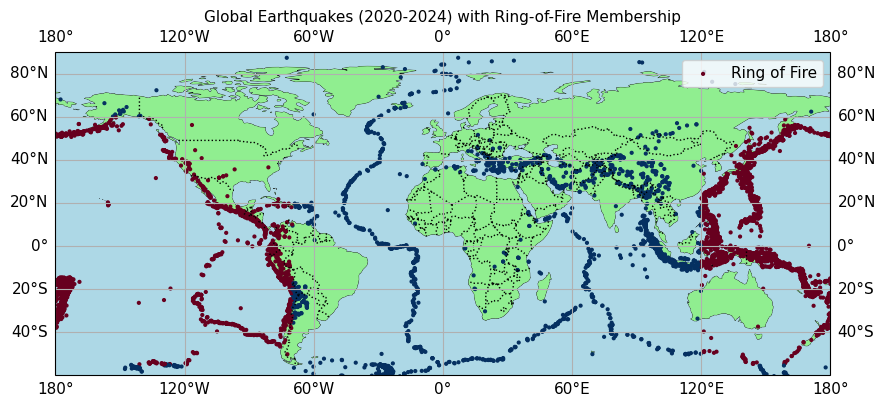

In [7]:
# Part 1: Labeling ring of fire membership
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Part 1.1: Define Ring-of-Fire polygon
df['ring'] = 0
# Western arm: longitude in [120°E, 180°E] and latitude in [−55°, 60°]
df.loc[(df['lon'] >= 120) & (df['lon'] <= 180) & (df['lat'] >= -55) & (df['lat'] <= 60), 'ring'] = 1
# Eastern arm: longitude in [−180°, −70°] and latitude in [−55°, 60°]
df.loc[(df['lon'] >= -180) & (df['lon'] <= -70) & (df['lat'] >= -55) & (df['lat'] <= 60), 'ring'] = 1

# Part 1.2: Visualize the labeling on a world map
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.LAND, facecolor='lightgreen', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.BORDERS, linestyle=':')

ax.title.set_text('Global Earthquakes (2020-2024) with Ring-of-Fire Membership')
ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
ax.scatter(df['lon'], df['lat'], c=df['ring'], s=4, cmap='RdBu_r',
transform=ccrs.PlateCarree())
ax.legend(['Ring of Fire', 'Non-Ring of Fire'], loc='upper right')
plt.show()

# Sanity-Check:
# The red points include Chile, Peru, Mexico, Japan, Indonesia, New Zealand, etc.

## Part 2 — Baseline: Geography Only (8 pts)

### Task 2.1 — k-Nearest Neighbors on (lat, lon) (4 pts)
Features: `[lat, lon]`. Label: `ring`. Standardize with `StandardScaler`, split 80/20, train a k-Nearest Neighbors classifier with $k$ chosen by simple grid search over {3, 5, 9, 15}. Report accuracy and the confusion matrix on the test set.

### Task 2.2 — Interpretation (4 pts)
Why does k-Nearest Neighbors do well here even without depth? What would you expect if you moved to a dataset with different spatial coverage (e.g. M4+ events, which densely sample continental-interior seismicity)?

In [8]:
# Part 2: Baseline: Geogtaphy Only
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler as SS

# Part 2.1: k-Nearest Neighbors (kNN) on latitude and longitude
X = df[['lat', 'lon']]
y = df['ring']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
print()

scaler = SS()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
param_grid = {'n_neighbors': [3, 5, 9, 15]}
knn = KNeighborsClassifier(n_neighbors=5)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
best_k = grid_search.best_params_['n_neighbors']
best_score = grid_search.best_score_
print(f"Best k value: {best_k}")
print(f"Best cross-validation accuracy: {best_score:.4f}")
print()

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
 

Training set size: 6948
Testing set size: 1738

Best k value: 3
Best cross-validation accuracy: 0.9935

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       574
           1       0.99      1.00      1.00      1164

    accuracy                           0.99      1738
   macro avg       0.99      0.99      0.99      1738
weighted avg       0.99      0.99      0.99      1738

Confusion Matrix:
[[ 568    6]
 [   5 1159]]


**Part 2.2: Interperetation**
The kNN model achieves an accuracy of 0.9935, it does this well with out depth because it uses the training data to find dirrect patterns in the data. If we changed data set the model would preform worse as it would receive data it was not trained on and would not know what to do with the new data.

## Part 3 — Adding Depth and Magnitude (12 pts)

### Task 3.1 — Random Forest on (lat, lon, depth, mag) (5 pts)
Re-train using all four features. Random Forest tolerates mixed scales, so you do not strictly need to standardize, but do it anyway for apples-to-apples comparison with Task 2. Report accuracy + confusion matrix.

### Task 3.2 — Feature importances (4 pts)
Plot the Random Forest's `feature_importances_` as a bar chart. Does depth actually help? By how much?

### Task 3.3 — Depth distribution by class (3 pts)
Side-by-side histograms of event depth for Ring-of-Fire vs. non-Ring events. Overlay the standard depth ranges:
- Shallow: 0–70 km
- Intermediate: 70–300 km
- Deep: >300 km

Comment on what you see.

In [9]:
# Part 3: Adding Depth and Magnitude
from sklearn.ensemble import RandomForestClassifier

# Part 3.1: Random Forest on latitude, longitude, depth, and magnitude
X = df[['lat', 'lon', 'depth', 'mag']]
y = df['ring']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
print()

scaler = SS()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f"Best parameters: {best_params}")
print(f"Best cross-validation accuracy: {best_score:.4f}")
print()
rf = RandomForestClassifier(**best_params, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Part 3.2: Feature Importance
importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)
print("Feature Importances:")
print(feature_importance_df)

Training set size: 6948
Testing set size: 1738

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best cross-validation accuracy: 0.9997

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       574
           1       1.00      1.00      1.00      1164

    accuracy                           1.00      1738
   macro avg       1.00      1.00      1.00      1738
weighted avg       1.00      1.00      1.00      1738

Confusion Matrix:
[[ 574    0]
 [   0 1164]]
Feature Importances:
  feature  importance
1     lon    0.769748
0     lat    0.213201
2   depth    0.015469
3     mag    0.001582


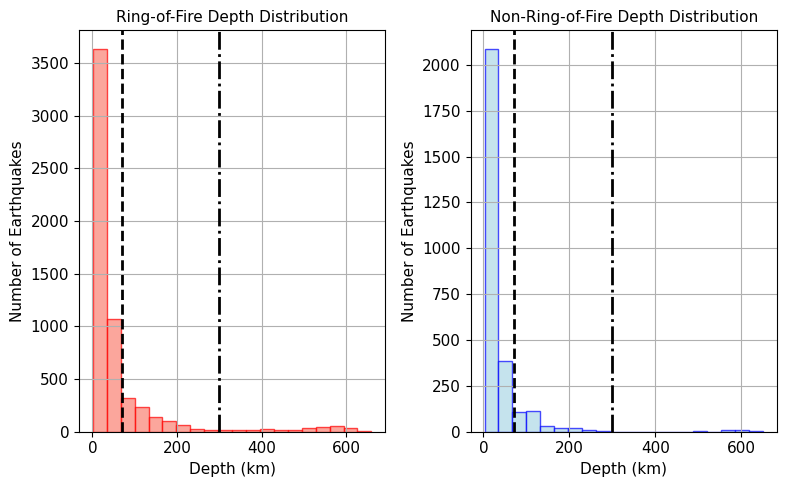

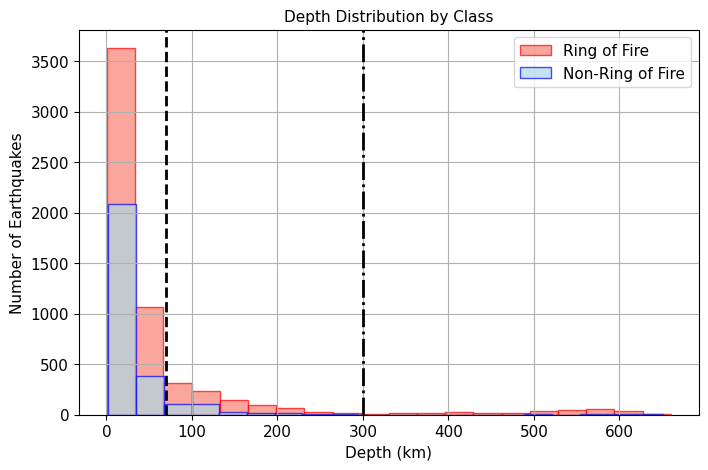

In [10]:
# Part 3.3: Depth Distribution by Class
plt.figure(figsize=(8, 5))

# Ring of Fire Histogram by Depth
plt.subplot(1, 2, 1)
ring_depths = df[df['ring'] == 1]['depth']
plt.hist(ring_depths, bins=20, alpha=0.7, color='salmon', edgecolor='red')
plt.axvline(x=70, color='black', linestyle='--', linewidth=2)
plt.axvline(x=300, color='black', linestyle='-.', linewidth=2)
plt.xlabel('Depth (km)')
plt.ylabel('Number of Earthquakes')
plt.title('Ring-of-Fire Depth Distribution')
plt.grid(True)


# Non-Ring of Fire Histogram
plt.subplot(1, 2, 2)
non_ring_depths = df[df['ring'] == 0]['depth']
plt.hist(non_ring_depths, bins=20, alpha=0.7, color='lightblue', edgecolor='blue')
plt.axvline(x=70, color='black', linestyle='--', linewidth=2)
plt.axvline(x=300, color='black', linestyle='-.', linewidth=2)
plt.xlabel('Depth (km)')
plt.ylabel('Number of Earthquakes')
plt.title('Non-Ring-of-Fire Depth Distribution')
plt.grid(True)
plt.tight_layout()
plt.show()

# Overlay of both histograms
plt.figure(figsize=(8, 5))
plt.hist(ring_depths, bins=20, alpha=0.7, color='salmon', edgecolor='red', label='Ring of Fire')
plt.hist(non_ring_depths, bins=20, alpha=0.7, color='lightblue', edgecolor='blue', label='Non-Ring of Fire')
plt.axvline(x=70, color='black', linestyle='--', linewidth=2)
plt.axvline(x=300, color='black', linestyle='-.', linewidth=2)
plt.xlabel('Depth (km)')
plt.ylabel('Number of Earthquakes')
plt.title('Depth Distribution by Class')
plt.legend()
plt.grid(True)
plt.show()

**Part 3.2**
Depth and magnitude don't play a big importance. Depth effects it by around 1.5%

**Part 3.3**
Most earthquakes occur from the 0-70km range. The Ring of Fire has more earthquakes and many more in the 300km+ range. Overall the average Ring of Fire earthquake occurs deeper in the ground.

## Part 4 — Decision Regions on the Map (8 pts)

### Task 4.1 — Dense (lat, lon) grid (3 pts)
Build a grid of candidate points covering the globe at ~2° resolution.

### Task 4.2 — Predict and overlay (5 pts)
For each grid point, predict Ring-of-Fire membership with your k-Nearest Neighbors model (and separately with Random Forest — fix depth and magnitude at their median values). Overlay the predicted region on a `cartopy` world map using semi-transparent filled contours. Add coastlines. Compare the shape to the real Ring-of-Fire.

Total candidate points: 13756
Total candidate points: 13756


/home/vscode/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


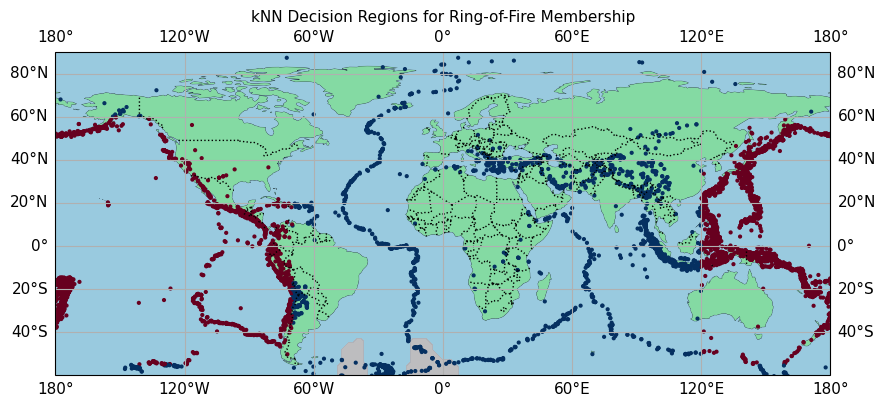

/home/vscode/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


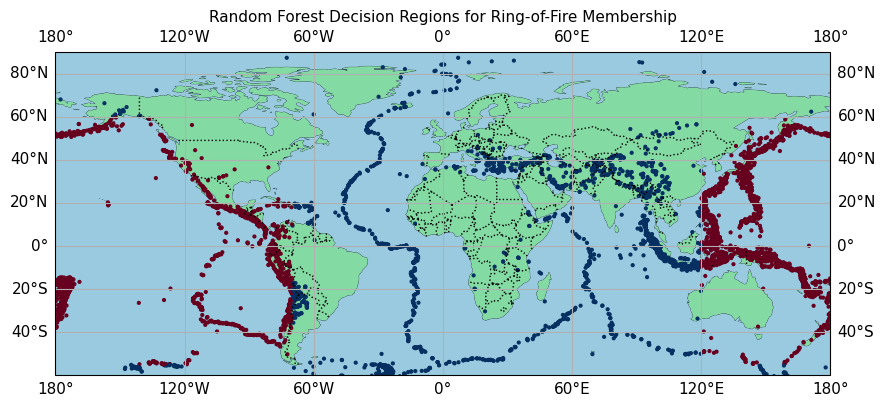

In [17]:
# Part 4: Decision Regions on the Map

# Part 4.1: Dense (lat, lon) grid
resolution = 2
lon = np.arange(-180, 180 + resolution, resolution)
lat = np.arange(-60, 90 + resolution, resolution)
lon_grid, lat_grid = np.meshgrid(lon, lat)
points = np.vstack([lon_grid.ravel(), lat_grid.ravel()]).T
print(f"Total candidate points: {len(points)}")

# Part 4.2: Predicting and overlay

# kNN decision regions
#For each grid point, predict Ring-of-Fire membership with your k-Nearest Neighbors model
# Part 4: Decision Regions on the Map

# Part 4.1: Dense (lat, lon) grid
resolution = 2
lon = np.arange(-180, 180 + resolution, resolution)
lat = np.arange(-60, 90 + resolution, resolution)
lon_grid, lat_grid = np.meshgrid(lon, lat)
points = np.vstack([lon_grid.ravel(), lat_grid.ravel()]).T
print(f"Total candidate points: {len(points)}")

# Part 4.2: Predicting and overlay

# kNN decision regions
# For each grid point, predict Ring-of-Fire membership with your k-Nearest Neighbors model
latlon_scaler = SS()
latlon_scaler.fit(df[['lat', 'lon']])
knn_predictions = knn.predict(latlon_scaler.transform(points))
knn_decision_map = knn_predictions.reshape(lon_grid.shape)
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={'projection': ccrs.PlateCarree()})
ax.contourf(lon_grid, lat_grid, knn_decision_map, alpha=0.3, cmap='RdBu_r', levels=[-0.5, 0.5, 1.5], transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgreen', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('kNN Decision Regions for Ring-of-Fire Membership')
ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
ax.scatter(df['lon'], df['lat'], c=df['ring'], s=4, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.show()

# Random Forest decision regions
median_depth = df['depth'].median()
median_mag = df['mag'].median()
points_rf = np.column_stack([points, np.full(len(points), median_depth), np.full(len(points), median_mag)])
rf_predictions = rf.predict(scaler.transform(points_rf))
rf_decision_map = rf_predictions.reshape(lon_grid.shape)
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={'projection': ccrs.PlateCarree()})
ax.contourf(lon_grid, lat_grid, rf_decision_map, alpha=0.3, cmap='RdBu_r', levels=[-0.5, 0.5, 1.5], transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgreen', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('Random Forest Decision Regions for Ring-of-Fire Membership')
ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
ax.scatter(df['lon'], df['lat'], c=df['ring'], s=4, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.show()





## Part 5 — Physics Discussion (6 pts)

Write 5–8 sentences addressing:
1. Which feature was most informative — latitude, longitude, depth, or magnitude? Does that match the physics of subduction vs. mid-ocean ridge seismicity?
2. Where did your classifier get it wrong? (e.g. the Mediterranean is seismically active but not in the Ring of Fire.)
3. If you wanted to recover the Ring-of-Fire *without* the polygon-based labels — i.e. unsupervised — what would you try? (Hint: think DBSCAN or KMeans in (lat, lon, depth) space.)

### Stretch (optional, bonus 4 pts)
Download the Bird (2003) tectonic-plate-boundary shapefile and overlay it on your decision-region plot. Comment on which boundary types (convergent, divergent, transform) your classifier captures well vs. poorly.

## Submission
**Good commit** ✅: `Add Random Forest model with depth and magnitude features`

**Bad commit** ❌: `fix`, `stuff`, `done`

### Checklist
- [ ] Notebook in `2026/FinalProject/<yourname>/`
- [ ] Runs top-to-bottom on a fresh kernel
- [ ] Type annotations and NumPy docstrings on your functions
- [ ] All plots labeled with units
- [ ] Tasks sum to ~42 points
- [ ] PR against `Homework2026`, reviewer `@laserlab`, milestone `Final-2026`
- [ ] AI usage disclosed in the PR description

## Resources
- [`libcomcat` documentation](https://code.usgs.gov/ghsc/esi/libcomcat-python)
- [USGS ComCat search parameters](https://earthquake.usgs.gov/fdsnws/event/1/)
- [Cartopy tutorial](https://scitools.org.uk/cartopy/docs/latest/tutorials/understanding_transform.html)
- Bird, P. (2003). *An updated digital model of plate boundaries.* Geochem. Geophys. Geosyst., 4(3).
- PHY386 plotting-style reference: [`2026/handson/ScientificPlottingMatplotlib.ipynb`](../handson/ScientificPlottingMatplotlib.ipynb)